In [1]:
# Importujeme pandas pro práci s tabulkami (je to takový Pythoní Excel)
import pandas as pd

# Importujeme RDKit, což je hlavní knihovna pro cheminformatiku
# Pomůže nám převést ty textové "SMILES" na skutečné molekuly
from rdkit import Chem

# Načtení tvých trénovacích dat (zkontroluj, že se soubor jmenuje přesně takhle 
# a je ve stejné složce jako tvůj Jupyter Notebook)
df_train = pd.read_csv('dataset-QSAR_90pct_reduced.csv')

# Zobrazíme si prvních 5 řádků, abychom zkontrolovali, že se data načetla správně
df_train.head()

,Ambit_InchiKey,Original_Entry_ID,Entrez_ID,Activity_Flag,pXC50,DB,Original_Assay_ID,Tax_ID,Gene_Symbol,Ortholog_Group,SMILES
0,CWYBNSVSYKQGJB-UHFFFAOYNA-N,71541095,6532,A,6.85387,pubchem,727355,9606,SLC6A4,4061,ClC=1C=C(C2CCCCNC2)C=CC1Cl
1,FQDRMHHCWZAXJM-UHFFFAOYNA-N,125558,25553,A,9.98297,pubchem,205028,10116,SLC6A4,4061,O1C=2C=C3CC(N)CC3=CC2OC1
2,QRAWNNQNLQPNIZ-UHFFFAOYNA-N,CHEMBL205229,6532,A,7.54000,chembl20,950695,9606,SLC6A4,4061,N1C=C(CCN)C2=C1C(=CC=C2)F
3,HCFHWXDIZOAUTQ-UHFFFAOYNA-N,CHEMBL6376,25553,A,6.11000,chembl20,201505,10116,SLC6A4,4061,C1(=CC=2OCOC2C=C1C)CC(N)C
4,JBDOSUUXMYMWQH-UHFFFAOYNA-N,CHEMBL1381098,6532,A,5.12000,chembl20,774720,9606,SLC6A4,4061,S=C=NC=1C=2C(C=CC1)=CC=CC2


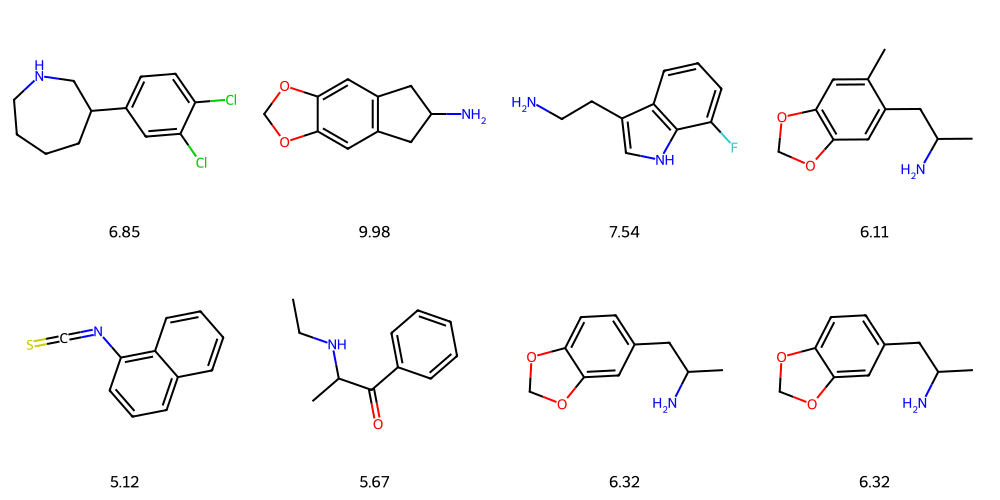

In [2]:
# Načteme modul pro kreslení z RDKitu
from rdkit.Chem import Draw

# 1. Vezmeme si prvních 8 textových SMILES z naší tabulky
sample_smiles = df_train['SMILES'].head(8).tolist()

# 2. Převedeme texty na skutečné chemické objekty (Molekuly), kterým RDKit rozumí
mols = [Chem.MolFromSmiles(smiles) for smiles in sample_smiles]

# 3. Připravíme si popisky pod obrázky - vezmeme k nim jejich hodnotu pXC50
# (zaokrouhlíme na 2 desetinná místa a převedeme na text)
sample_pxc50 = df_train['pXC50'].head(8).round(2).astype(str).tolist()

# 4. Vykreslíme je jako mřížku obrázků
img = Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(250, 250), legends=sample_pxc50)

# Tento příkaz zajistí, že se obrázek zobrazí přímo v Jupyteru
img

In [3]:
import numpy as np
from rdkit.Chem import AllChem

# Funkce, která vezme text (SMILES) a vyrobí z něj seznam čísel (Fingerprint)
def smiles_to_fp(smiles, radius=2, nBits=2048):
    # 1. Převedeme text na objekt molekuly
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    
    # 2. Vygenerujeme Morganův fingerprint (to je standard v oboru)
    # Radius 2 odpovídá zhruba okolí 2 vazeb od každého atomu
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)
    
    # 3. Převedeme to na pole čísel (numpy array), se kterým umí pracovat AI
    return np.array(fp)

# Teď funkci aplikujeme na celý náš trénovací dataset (90%)
# Vytvoříme seznam všech fingerprintů
X_train = np.array([smiles_to_fp(s) for s in df_train['SMILES']])

# A do proměnné 'y' si uložíme to, co chceme předpovídat (naše cílová hodnota)
y_train = df_train['pXC50'].values

print(f"Hotovo! Máme připraveno {X_train.shape[0]} molekul.")
print(f"Každá molekula je teď popsána {X_train.shape[1]} čísly (nulami a jedničkami).")

[09:28:04] DEPRECATION WARNING: please use MorganGenerator
[09:28:04] DEPRECATION WARNING: please use MorganGenerator
[09:28:04] DEPRECATION WARNING: please use MorganGenerator
[09:28:04] DEPRECATION WARNING: please use MorganGenerator
[09:28:04] DEPRECATION WARNING: please use MorganGenerator
[09:28:04] DEPRECATION WARNING: please use MorganGenerator
[09:28:04] DEPRECATION WARNING: please use MorganGenerator
[09:28:04] DEPRECATION WARNING: please use MorganGenerator
[09:28:04] DEPRECATION WARNING: please use MorganGenerator
[09:28:04] DEPRECATION WARNING: please use MorganGenerator
[09:28:04] DEPRECATION WARNING: please use MorganGenerator
[09:28:04] DEPRECATION WARNING: please use MorganGenerator
[09:28:04] DEPRECATION WARNING: please use MorganGenerator
[09:28:04] DEPRECATION WARNING: please use MorganGenerator
[09:28:04] DEPRECATION WARNING: please use MorganGenerator
[09:28:04] DEPRECATION WARNING: please use MorganGenerator
[09:28:04] DEPRECATION WARNING: please use MorganGenerat

Hotovo! Máme připraveno 6506 molekul.
Každá molekula je teď popsána 2048 čísly (nulami a jedničkami).


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1. Rozdělíme naše 90% data na "pod-trénovací" (80 %) a "validační" (20 %)
# Díky tomu uvidíme, jak moc se model plete, než odevzdáme úkol.
X_sub_train, X_val, y_sub_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# 2. Vytvoříme model "Náhodný les"
# n_estimators=100 znamená, že vytvoříme 100 různých stromů, které budou společně hlasovat
model = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)

print("Trénuji model... (může to chvilku trvat)")

# 3. Teď se model "učí"
model.fit(X_sub_train, y_sub_train)

# 4. Zkusíme, co si model myslí o datech, která jsme mu schovali (X_val)
predictions = model.predict(X_val)

# 5. Vypočítáme chybu
rmse = np.sqrt(mean_squared_error(y_val, predictions))
r2 = r2_score(y_val, predictions)

print(f"Hotovo! Model je vytrénovaný.")
print(f"Průměrná chyba (RMSE): {rmse:.3f}")
print(f"Přesnost (R2 skóre): {r2:.3f}")

Trénuji model... (může to chvilku trvat)
Hotovo! Model je vytrénovaný.
Průměrná chyba (RMSE): 0.687
Přesnost (R2 skóre): 0.659


In [6]:
# 1. Načteme ten druhý soubor (10% testovací data bez pXC50)
df_test = pd.read_csv('dataset-QSAR_10pct_test_dataset_nopXC50.csv')

# 2. Převedeme SMILES v testovacím datasetu na fingerprinty (stejně jako u trénovacích)
X_test_final = np.array([smiles_to_fp(s) for s in df_test['SMILES']])

# 3. Teď použijeme náš hotový model k predikci (výpočtu) pXC50
final_predictions = model.predict(X_test_final)

# 4. Výsledky si přidáme do tabulky k těm testovacím datům
df_test['predicted_pXC50'] = final_predictions

# 5. Uložíme výsledek do nového CSV souboru, který pak můžeš odevzdat
df_test.to_csv('vysledky_predikce_QSAR.csv', index=False)

print("Hotovo! Predikce jsou vypočítány.")
print(f"Vytvořili jsme odhady pro {len(df_test)} látek.")
print("Soubor 'vysledky_predikce_QSAR.csv' byl uložen ve stejné složce jako tento notebook.")

# Zobrazíme si prvních pár řádků s našimi odhady
df_test[['Original_Entry_ID', 'SMILES', 'predicted_pXC50']].head()

[09:31:50] DEPRECATION WARNING: please use MorganGenerator
[09:31:50] DEPRECATION WARNING: please use MorganGenerator
[09:31:50] DEPRECATION WARNING: please use MorganGenerator
[09:31:50] DEPRECATION WARNING: please use MorganGenerator
[09:31:50] DEPRECATION WARNING: please use MorganGenerator
[09:31:50] DEPRECATION WARNING: please use MorganGenerator
[09:31:50] DEPRECATION WARNING: please use MorganGenerator
[09:31:50] DEPRECATION WARNING: please use MorganGenerator
[09:31:50] DEPRECATION WARNING: please use MorganGenerator
[09:31:50] DEPRECATION WARNING: please use MorganGenerator
[09:31:50] DEPRECATION WARNING: please use MorganGenerator
[09:31:50] DEPRECATION WARNING: please use MorganGenerator
[09:31:50] DEPRECATION WARNING: please use MorganGenerator
[09:31:50] DEPRECATION WARNING: please use MorganGenerator
[09:31:50] DEPRECATION WARNING: please use MorganGenerator
[09:31:50] DEPRECATION WARNING: please use MorganGenerator
[09:31:50] DEPRECATION WARNING: please use MorganGenerat

Hotovo! Predikce jsou vypočítány.
Vytvořili jsme odhady pro 722 látek.
Soubor 'vysledky_predikce_QSAR.csv' byl uložen ve stejné složce jako tento notebook.


[09:31:51] DEPRECATION WARNING: please use MorganGenerator
[09:31:51] DEPRECATION WARNING: please use MorganGenerator
[09:31:51] DEPRECATION WARNING: please use MorganGenerator
[09:31:51] DEPRECATION WARNING: please use MorganGenerator
[09:31:51] DEPRECATION WARNING: please use MorganGenerator
[09:31:51] DEPRECATION WARNING: please use MorganGenerator
[09:31:51] DEPRECATION WARNING: please use MorganGenerator
[09:31:51] DEPRECATION WARNING: please use MorganGenerator
[09:31:51] DEPRECATION WARNING: please use MorganGenerator
[09:31:51] DEPRECATION WARNING: please use MorganGenerator
[09:31:51] DEPRECATION WARNING: please use MorganGenerator
[09:31:51] DEPRECATION WARNING: please use MorganGenerator
[09:31:51] DEPRECATION WARNING: please use MorganGenerator
[09:31:51] DEPRECATION WARNING: please use MorganGenerator
[09:31:51] DEPRECATION WARNING: please use MorganGenerator
[09:31:51] DEPRECATION WARNING: please use MorganGenerator
[09:31:51] DEPRECATION WARNING: please use MorganGenerat

,Original_Entry_ID,SMILES,predicted_pXC50
0,CHEMBL728,N1(C=2C(=CC=C(C2)Cl)SC=3C1=CC=CC3)CCCN4CCN(CC4)C,6.767690
1,10502796,FC(F)(F)C1=CC(COCC2(CCN(CC2)C)C3=CC=CC=C3)=CC(...,7.126402
2,54757021,S1(=O)(=O)N(CCC2OCCNC2)C3=C(N1C=4C(F)=CC=CC4)C...,6.073119
3,72793695,FC1=CC=C(C2(OCC3=C2C=CC(=C3)C#N)CCCN(CC=4C=5C(...,5.831749
4,CHEMBL60167,N=1C2=C(C=CC=C2)C(N)=C3C1C4=C(C3)C=CC=C4,5.780848


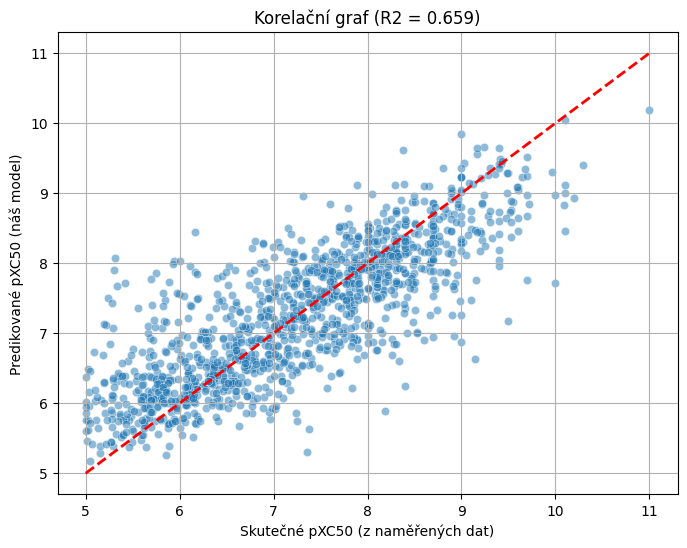

In [ ]:
import seaborn as sns

# Vytvoříme graf: Skutečné hodnoty vs. Naše predikce
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_val, y=predictions, alpha=0.5)

# Přidáme diagonální čáru - pokud by model byl 100% přesný, všechny body leží na ní
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)

plt.xlabel('Skutečné pXC50 (z naměřených dat)')
plt.ylabel('Predikované pXC50 (náš model)')
plt.title(f'Korelační graf (R2 = {r2:.3f})')
plt.grid(True)
plt.show()